In [1]:
import os
import torch
import math
import cv2
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from collections import Counter
from sklearn.model_selection import train_test_split
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split, WeightedRandomSampler
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights

device = "cuda" if torch.cuda.is_available() else "cpu"

In [2]:
import random
import numpy as np
import torch

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [3]:
MAG = "200X"   # 100X, 200X, 400X
DATA_ROOT = "/kaggle/input/breakhis/BreaKHis_v1//BreaKHis_v1/histology_slides/breast"


In [4]:
CLASS_NAMES = [
    "adenosis",
    "fibroadenoma",
    "phyllodes_tumor",
    "tubular_adenoma",
    "ductal_carcinoma",
    "lobular_carcinoma",
    "mucinous_carcinoma",
    "papillary_carcinoma"
]

class_to_idx = {cls: i for i, cls in enumerate(CLASS_NAMES)}


In [5]:
BENIGN_CLASSES = {
    "adenosis",
    "fibroadenoma",
    "phyllodes_tumor",
    "tubular_adenoma"
}

MALIGNANT_CLASSES = {
    "ductal_carcinoma",
    "lobular_carcinoma",
    "mucinous_carcinoma",
    "papillary_carcinoma"
}


In [6]:
def load_breakhis(mag="200X"):
    samples = []

    for root, _, files in os.walk(DATA_ROOT):
        if not root.endswith(mag):
            continue

        parts = root.split(os.sep)

        cls = None
        for c in CLASS_NAMES:
            if c in parts:
                cls = c
                break

        if cls is None:
            continue

        label = class_to_idx[cls]

        for f in files:
            if f.lower().endswith(".png"):
                samples.append((os.path.join(root, f), label))

    return samples


In [7]:
samples = load_breakhis("200X")



In [8]:
from PIL import Image
from torch.utils.data import Dataset

class BreakHisDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, label


In [9]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((230, 230)),
    transforms.RandomRotation(1),
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

val_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])



In [10]:
train_samples, temp_samples = train_test_split(
    samples,
    test_size=0.2,
    stratify=[s[1] for s in samples],
    random_state=42
)

val_samples, test_samples = train_test_split(
    temp_samples,  
    test_size=0.5,
    stratify=[s[1] for s in temp_samples],
    random_state=42
)

print("Train:", len(train_samples))
print("Val:", len(val_samples))
print("Test:", len(test_samples))



Train: 1610
Val: 201
Test: 202


In [11]:
train_ds = BreakHisDataset(train_samples, train_tf)
val_ds   = BreakHisDataset(val_samples, val_tf)
test_ds  = BreakHisDataset(test_samples, val_tf)


In [12]:
train_labels = [s[1] for s in train_samples]
class_sample_count = Counter(train_labels)

weights = 1. / torch.tensor(
    [class_sample_count[i] for i in range(len(CLASS_NAMES))],
    dtype=torch.float
)

samples_weights = torch.tensor([weights[t] for t in train_labels])
sampler = WeightedRandomSampler(samples_weights, len(samples_weights))

In [13]:
import matplotlib.pyplot as plt
from collections import Counter

def analyze_dataset(samples, title):
    labels = [s[1] for s in samples]
    counter = Counter(labels)

    benign_count = 0
    malignant_count = 0

    for label, count in counter.items():
        class_name = CLASS_NAMES[label]
        if class_name in BENIGN_CLASSES:
            benign_count += count
        else:
            malignant_count += count

    total = benign_count + malignant_count

    print(f"{title}")
    print(f" Total images     : {total}")
    print(f" Benign (lành)    : {benign_count}")
    print(f" Malignant (ác)   : {malignant_count}")
    print("-" * 40)

    # visualize
    plt.figure(figsize=(5,4))
    plt.bar(
        ["Benign", "Malignant"],
        [benign_count, malignant_count],
        color=["green", "red"]
    )
    plt.title(title)
    plt.ylabel("Number of images")
    plt.tight_layout()
    plt.show()


Original dataset
 Total images     : 2013
 Benign (lành)    : 623
 Malignant (ác)   : 1390
----------------------------------------


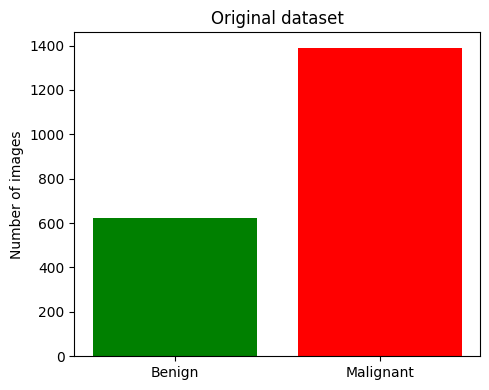

Training set (80%)
 Total images     : 1610
 Benign (lành)    : 498
 Malignant (ác)   : 1112
----------------------------------------


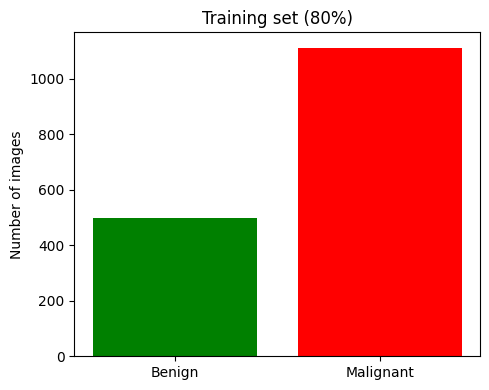

In [14]:
analyze_dataset(samples, "Original dataset")

analyze_dataset(train_samples, "Training set (80%)")



In [15]:
import matplotlib.pyplot as plt
from collections import Counter

def analyze_and_plot(samples, title):
    labels = [s[1] for s in samples]
    counter = Counter(labels)

    class_counts = []
    colors = []

    benign_total = 0
    malignant_total = 0

    for i, name in enumerate(CLASS_NAMES):
        n = counter.get(i, 0)
        class_counts.append(n)

        if name in BENIGN_CLASSES:
            colors.append("green")
            benign_total += n
        else:
            colors.append("red")
            malignant_total += n

    total = benign_total + malignant_total

    # ===== print summary =====
    print(f"\n{title}")
    print("-" * 45)
    print(f" Total images     : {total}")
    print(f" Benign (lành)    : {benign_total}")
    print(f" Malignant (ác)   : {malignant_total}")
    print("\nPer-class breakdown:")
    for i, name in enumerate(CLASS_NAMES):
        print(f" {name:20s}: {class_counts[i]}")
    print("-" * 45)

    # ===== visualize =====
    plt.figure(figsize=(10,4))
    plt.bar(range(len(CLASS_NAMES)), class_counts, color=colors)
    plt.xticks(range(len(CLASS_NAMES)), CLASS_NAMES, rotation=45, ha="right")
    plt.ylabel("Number of images")
    plt.title(f"{title} (green: benign, red: malignant)")
    plt.tight_layout()
    plt.show()



Original dataset
---------------------------------------------
 Total images     : 2013
 Benign (lành)    : 623
 Malignant (ác)   : 1390

Per-class breakdown:
 adenosis            : 111
 fibroadenoma        : 264
 phyllodes_tumor     : 108
 tubular_adenoma     : 140
 ductal_carcinoma    : 896
 lobular_carcinoma   : 163
 mucinous_carcinoma  : 196
 papillary_carcinoma : 135
---------------------------------------------


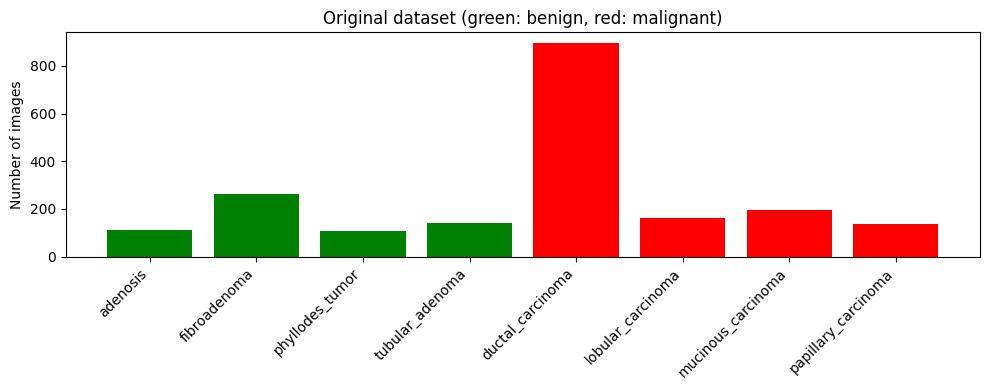


Training set (80%)
---------------------------------------------
 Total images     : 1610
 Benign (lành)    : 498
 Malignant (ác)   : 1112

Per-class breakdown:
 adenosis            : 89
 fibroadenoma        : 211
 phyllodes_tumor     : 86
 tubular_adenoma     : 112
 ductal_carcinoma    : 717
 lobular_carcinoma   : 130
 mucinous_carcinoma  : 157
 papillary_carcinoma : 108
---------------------------------------------


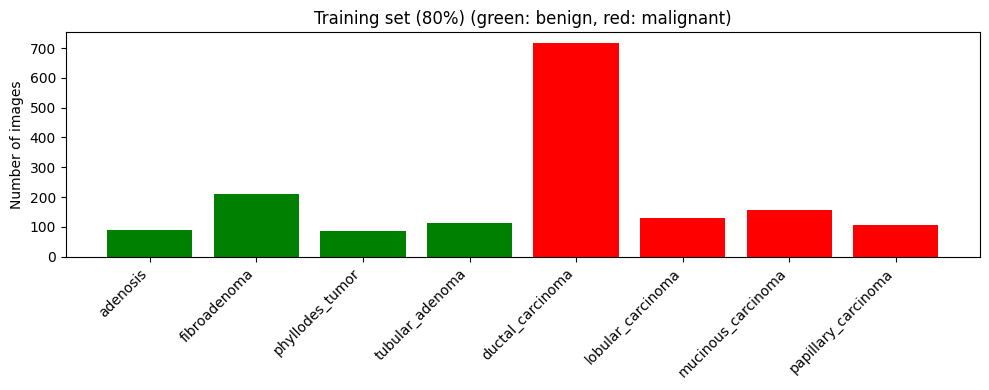

In [16]:
analyze_and_plot(samples, "Original dataset")
analyze_and_plot(train_samples, "Training set (80%)")


In [17]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_ds,
    batch_size=32,
    sampler=sampler,  
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(  
    test_ds,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [18]:
class ECA(nn.Module):
    def __init__(self, channels, k_size=3):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.conv = nn.Conv1d(
            1, 1, kernel_size=k_size,
            padding=(k_size - 1) // 2,
            bias=False
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        y = self.avg_pool(x)
        y = self.conv(y.squeeze(-1).transpose(-1, -2))
        y = self.sigmoid(y).transpose(-1, -2).unsqueeze(-1)
        return x * y.expand_as(x)


class ConvNeXtECA(nn.Module):
    def __init__(self, num_classes=8):
        super().__init__()

        backbone = models.convnext_tiny(weights='IMAGENET1K_V1')

        self.features = backbone.features  # (B, 768, 7, 7)

        self.eca = ECA(768)

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.head = nn.Sequential(
            nn.Flatten(),
            nn.LayerNorm(768),
            nn.Dropout(0.5),
            nn.Linear(768, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.eca(x)
        x = self.pool(x)
        return self.head(x)

In [19]:
from tqdm import tqdm

def train_one_epoch(model, loader, epoch, epochs):
    model.train()
    total_loss, correct, total = 0, 0, 0

    pbar = tqdm(loader, desc=f"Epoch [{epoch}/{epochs}]", leave=False)

    for imgs, labels in pbar:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(imgs)
        loss = criterion(outputs, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)

        optimizer.step()
        scheduler.step()   

        total_loss += loss.item()
        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        pbar.set_postfix(
            loss=f"{loss.item():.4f}",
            acc=f"{correct/total:.4f}"
        )

    return total_loss / len(loader), correct / total

In [20]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def evaluate_full(model, loader):
    model.eval()

    y_true, y_pred = [], []

    total_loss = 0 

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            preds = outputs.argmax(1).cpu().numpy()

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds)

    overall_acc = accuracy_score(y_true, y_pred)
    avg_prec, avg_rec, avg_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro"
    )

    return overall_acc, avg_prec, avg_rec, avg_f1,y_true,y_pred,total_loss / len(loader)

In [21]:
EPOCHS = 100
patience = 25
seed = 42
set_seed(seed)

model = ConvNeXtECA(num_classes=8).to(device)

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

total_params = count_params(model)
print("Total trainable params:", total_params)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,         
    weight_decay=1e-2
)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=1e-4,  
    steps_per_epoch=len(train_loader),
    epochs=EPOCHS,
    pct_start=0.3
)

criterion = nn.CrossEntropyLoss(
    label_smoothing=0.15
)

train_losses, val_losses = [], []
train_accs, val_accs = [], []

best_f1 = 0
best_epoch = 0
best_state = None
best_acc = 0
best_prec = 0
best_rec = 0
patience_cnt = 0

for epoch in range(1, EPOCHS + 1):

    curr_lr = scheduler.get_last_lr()[0]

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        epoch,
        EPOCHS
    )

    acc, prec, rec, f1, y_true, y_pred, val_loss = evaluate_full(
        model,
        val_loader
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(acc)

    # --- PRINT ---
    print(f"\nEpoch {epoch}/{EPOCHS} | LR: {curr_lr:.2e}")
    print(f"Train loss : {train_loss:.4f}")
    print(f"Train acc  : {train_acc*100:.2f}%")
    print(f"Val loss  : {val_loss:.4f}")
    print(f"Val acc   : {acc*100:.2f}%")
    print(f"Precision  : {prec*100:.2f}%")
    print(f"Recall     : {rec*100:.2f}%")
    print(f"F1-score   : {f1*100:.2f}%")

    if f1 > best_f1 + 1e-4:
        best_f1 = f1
        best_epoch = epoch
        best_state = model.state_dict()
        best_acc, best_prec, best_rec = acc, prec, rec
        best_pred = (y_true,y_pred)

        torch.save(best_state, "best_model_200X.pth")
        print("Best model saved!")
        patience_cnt = 0
    else:
        patience_cnt += 1

    if patience_cnt >= patience:
        print(f"\n Early stopping at epoch {epoch}")
        break

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 209MB/s] 


Total trainable params: 27826283



Epoch 1/100 | LR: 4.00e-06
Train loss : 2.3090
Train acc  : 13.17%
Val loss  : 2.0886
Val acc   : 20.90%
Precision  : 24.51%
Recall     : 27.00%
F1-score   : 19.49%
Best model saved!



Epoch 2/100 | LR: 4.26e-06
Train loss : 2.1343
Train acc  : 20.50%
Val loss  : 1.9093
Val acc   : 34.83%
Precision  : 31.72%
Recall     : 39.47%
F1-score   : 30.60%
Best model saved!


...


Epoch 49/100 | LR: 8.45e-05
Train loss : 0.6656
Train acc  : 99.50%
Val loss  : 0.8466
Val acc   : 89.55%
Precision  : 89.33%
Recall     : 86.58%
F1-score   : 87.65%



Epoch 50/100 | LR: 8.29e-05
Train loss : 0.6689
Train acc  : 99.25%
Val loss  : 0.7997
Val acc   : 91.54%
Precision  : 91.91%
Recall     : 90.25%
F1-score   : 89.85%



Epoch 51/100 | LR: 8.11e-05
Train loss : 0.6713
Train acc  : 99.13%
Val loss  : 0.8123
Val acc   : 91.04%
Precision  : 91.76%
Recall     : 87.92%
F1-score   : 88.74%



Epoch 52/100 | LR: 7.94e-05
Train loss : 0.6723
Train acc  : 99.01%
Val loss  : 0.8006
Val acc   : 92.04%
Precision  : 92.35%
Recall     : 91.31%
F1-score   : 91.46%



Epoch 53/100 | LR: 7.75e-05
Train loss : 0.6611
Train acc  : 99.69%
Val loss  : 0.7765
Val acc   : 94.03%
Precision  : 93.97%
Recall     : 93.22%
F1-score   : 92.80%

 Early stopping at epoch 53


In [22]:
model.load_state_dict(best_state)

print("\n" + "="*60)
print("BEST MODEL ON VAL RESULTS")
print("="*60)

print(f"Best epoch : {best_epoch}")
print(f"Accuracy   : {best_acc*100:.2f}%")
print(f"Precision  : {best_prec*100:.2f}%")
print(f"Recall     : {best_rec*100:.2f}%")
print(f"F1-score   : {best_f1*100:.2f}%")
print("="*60)


BEST MODEL ON VAL RESULTS
Best epoch : 28
Accuracy   : 95.02%
Precision  : 94.53%
Recall     : 94.88%
F1-score   : 94.39%


In [23]:
# Load lại model tốt nhất
model = ConvNeXtECA(num_classes=8).to(device)
model.load_state_dict(torch.load("best_model_200X.pth"))
model.eval()

# Evaluate trên test set
test_acc, test_prec, test_rec, test_f1, y_true, y_pred, test_loss = evaluate_full(
    model,
    test_loader
)

# In kết quả
print("\n" + "="*60)
print("TEST SET RESULTS (BEST MODEL)")
print("="*60)

print(f"Test loss  : {test_loss:.4f}")
print(f"Accuracy   : {test_acc*100:.2f}%")
print(f"Precision  : {test_prec*100:.2f}%")
print(f"Recall     : {test_rec*100:.2f}%")
print(f"F1-score   : {test_f1*100:.2f}%")

print("="*60)


TEST SET RESULTS (BEST MODEL)
Test loss  : 0.8035
Accuracy   : 92.08%
Precision  : 91.43%
Recall     : 92.93%
F1-score   : 91.94%


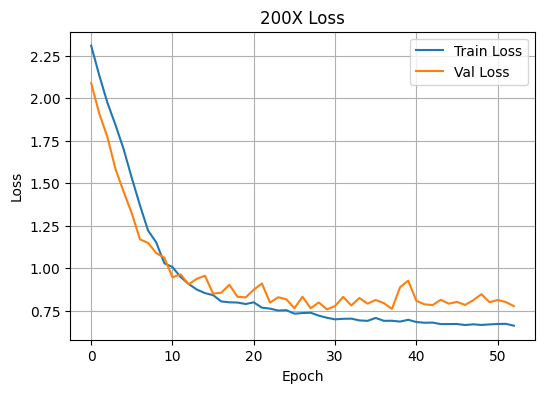

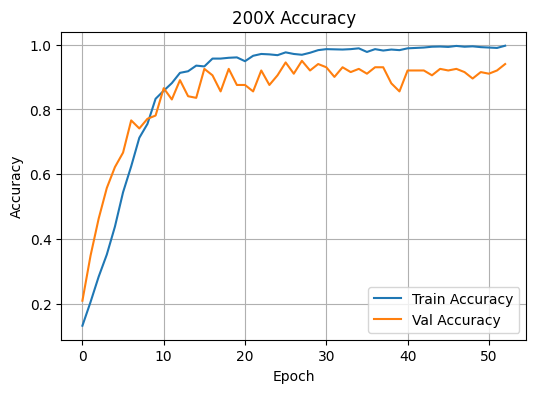

In [24]:
import matplotlib.pyplot as plt

# Loss
plt.figure(figsize=(6,4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("200X Loss")
plt.legend()
plt.grid()
plt.show()

# Accuracy
plt.figure(figsize=(6,4))
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("200X Accuracy")
plt.legend()
plt.grid()
plt.show()

In [25]:
y_true, y_pred = best_pred
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))


Classification Report:
                     precision    recall  f1-score   support

           adenosis       1.00      1.00      1.00        11
       fibroadenoma       1.00      0.96      0.98        26
    phyllodes_tumor       1.00      0.91      0.95        11
    tubular_adenoma       1.00      0.93      0.96        14
   ductal_carcinoma       0.98      0.96      0.97        89
  lobular_carcinoma       0.76      0.94      0.84        17
 mucinous_carcinoma       1.00      0.89      0.94        19
papillary_carcinoma       0.82      1.00      0.90        14

           accuracy                           0.95       201
          macro avg       0.95      0.95      0.94       201
       weighted avg       0.96      0.95      0.95       201



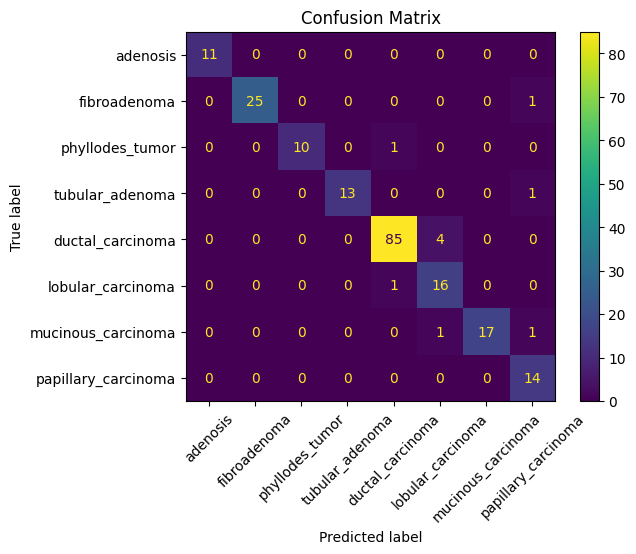

In [26]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
disp.plot(xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

In [27]:
features, gradients = [], []

def forward_hook(module, input, output):
    features.clear()
    features.append(output)

def backward_hook(module, grad_input, grad_output):
    gradients.clear()
    gradients.append(grad_output[0])

target_layer = model.features[-1]
target_layer.register_forward_hook(forward_hook)
target_layer.register_full_backward_hook(backward_hook)

def grad_cam_single(img, class_idx):
    model.eval()
    img = img.unsqueeze(0).to(device)

    features.clear()
    gradients.clear()

    out = model(img)
    model.zero_grad()

    out[0, class_idx].backward()

    fmap = features[0]
    grad = gradients[0]

    weights = grad.mean(dim=(2,3), keepdim=True)
    cam = (weights * fmap).sum(dim=1).squeeze()

    cam = cam.detach().cpu().numpy()
    cam = np.maximum(cam, 0)

    if cam.max() != 0:
        cam = cam / cam.max()

    return cam

def grad_cam_all_classes(img):
    cams = []
    for class_idx in range(len(CLASS_NAMES)):
        cam = grad_cam_single(img, class_idx)
        cam = cv2.resize(cam, (224,224))
        cams.append(cam)
    return cams

In [28]:
from sklearn.metrics import f1_score

# lấy kết quả tốt nhất từ training
y_true, y_pred = best_pred

# tính F1 từng class
f1_per_class = f1_score(y_true, y_pred, average=None)

# chọn class tốt nhất
best_class_idx = np.argmax(f1_per_class)

print("Best class:", CLASS_NAMES[best_class_idx])

Best class: adenosis


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


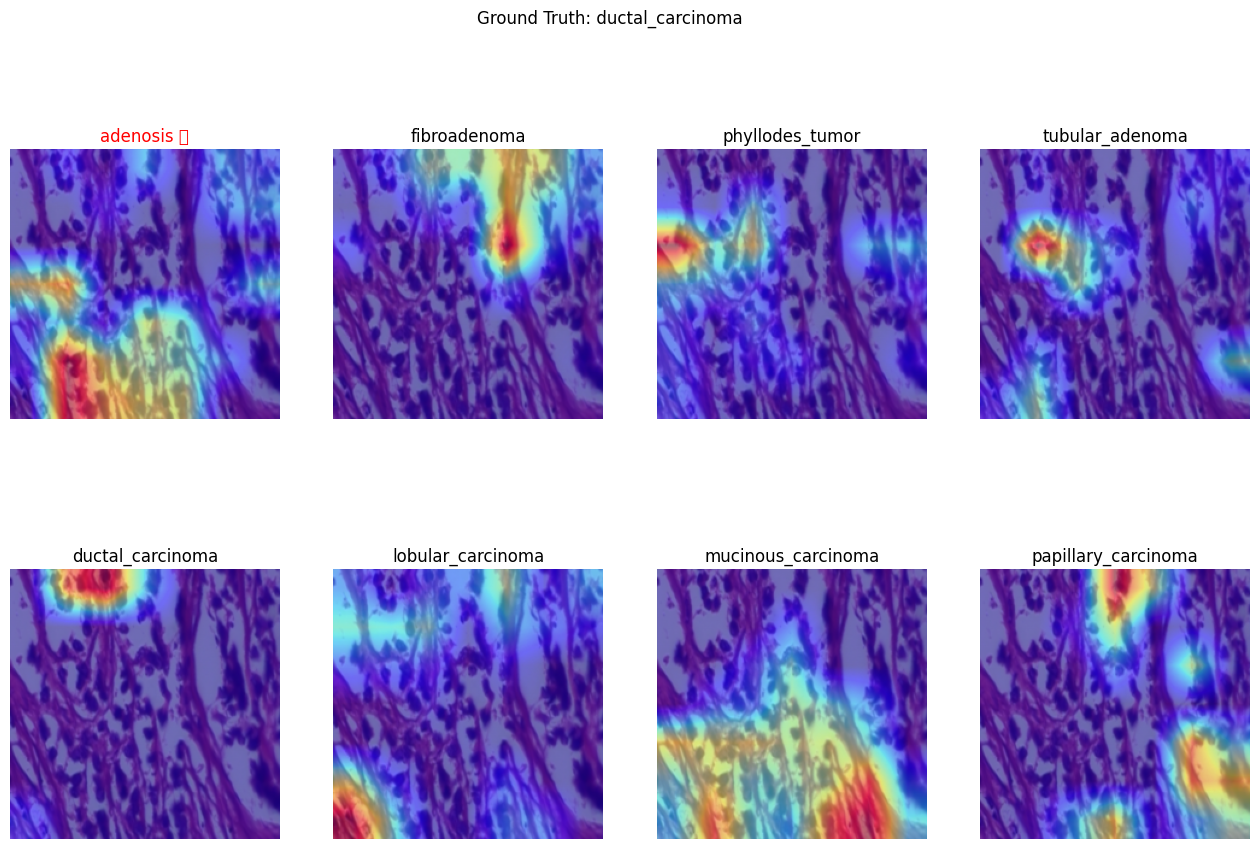

In [29]:
img, label = test_ds[0]
cams = grad_cam_all_classes(img)

img_np = img.permute(1,2,0).numpy()
img_np = (img_np - img_np.min())/(img_np.max()-img_np.min())

plt.figure(figsize=(16,10))
for i, cam in enumerate(cams):
    plt.subplot(2,4,i+1)
    plt.imshow(img_np)
    plt.imshow(cam, cmap='jet', alpha=0.5)

    if i == best_class_idx:
        plt.title(f"{CLASS_NAMES[i]} ⭐", color='red')
    else:
        plt.title(CLASS_NAMES[i])

    plt.axis('off')

plt.suptitle(f"Ground Truth: {CLASS_NAMES[label]}")
plt.show()